In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import gc
import time

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)

IMG_SIZE = (224, 224)
NUM_CLASSES = 37

print("Setup complete.")

/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

TensorFlow: 2.20.0
TFDS: 4.9.10
Setup complete.


In [ ]:
!pip install -q protobuf==6.31.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 8.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [ ]:
!pip install -q importlib_resources

In [ ]:
print("Loading Oxford-IIIT Pet Dataset...")

(train_raw, val_raw, test_raw), info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]", "test"],
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully.")

print("Training samples:",
      tf.data.experimental.cardinality(train_raw).numpy())

print("Validation samples:",
      tf.data.experimental.cardinality(val_raw).numpy())

print("Test samples:",
      tf.data.experimental.cardinality(test_raw).numpy())

print("Number of classes:",
      info.features["label"].num_classes)

Loading Oxford-IIIT Pet Dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.GM8KNH_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.GM8KNH_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Dataset loaded successfully.
Training samples: 2944
Validation samples: 736
Test samples: 3669
Number of classes: 37


In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


train_dataset = train_raw.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_raw.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_raw.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Preprocessing prepared successfully.")

Preprocessing prepared successfully.


In [ ]:
print("Creating MobileNetV2 feature extractor...")

feature_extractor = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

feature_extractor.trainable = False

feature_model = tf.keras.Sequential([
    feature_extractor,
    layers.GlobalAveragePooling2D()
])

print("Feature extractor created successfully.")

Creating MobileNetV2 feature extractor...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extractor created successfully.


In [ ]:
def extract_features(dataset, batch_size=16):
    features = []
    labels = []

    dataset = dataset.batch(batch_size)

    for images, batch_labels in dataset:
        batch_features = feature_model(images, training=False)

        features.append(batch_features.numpy())
        labels.append(batch_labels.numpy())

        del batch_features

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)

    return features, labels


print("Extracting MobileNetV2 features...")
print("This may take a few minutes.")

X_train_features, y_train = extract_features(
    train_dataset,
    batch_size=16
)

print("Feature extraction completed!")
print("Feature shape:", X_train_features.shape)
print("Labels shape:", y_train.shape)


Extracting MobileNetV2 features...
This may take a few minutes.
Feature extraction completed!
Feature shape: (2944, 1280)
Labels shape: (2944,)


In [ ]:
# Free MobileNetV2 memory before cross-validation

del feature_model
del feature_extractor
gc.collect()

print("MobileNetV2 cleared from memory.")
print("Training features are safely stored.")

MobileNetV2 cleared from memory.
Training features are safely stored.


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_splits = list(kf.split(X_train_features))

print("5-Fold Cross-Validation prepared.")
print("Total samples:", len(X_train_features))

for i, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    print(
        f"Fold {i}: "
        f"Training = {len(train_idx)}, "
        f"Validation = {len(val_idx)}"
    )

5-Fold Cross-Validation prepared.
Total samples: 2944
Fold 1: Training = 2355, Validation = 589
Fold 2: Training = 2355, Validation = 589
Fold 3: Training = 2355, Validation = 589
Fold 4: Training = 2355, Validation = 589
Fold 5: Training = 2356, Validation = 588


In [ ]:
def create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
):

    model = models.Sequential([
        layers.Input(shape=(1280,)),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(dropout),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    if optimizer_name.lower() == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name.lower() == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    else:
        raise ValueError("Unsupported optimizer")

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("CV model function created successfully.")

CV model function created successfully.


In [ ]:
# ============================================================
# C1 - FOLD 1
# Adam | LR = 0.001 | Dropout = 0.25 | Batch Size = 32
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[0]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]

X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c1_f1 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=32,
    verbose=1
)

c1_f1_loss, c1_f1_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=32,
    verbose=1
)

print(f"C1 Fold 1 Validation Accuracy: {c1_f1_accuracy * 100:.2f}%")
print(f"C1 Fold 1 Validation Loss: {c1_f1_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5890 - loss: 1.5742 - val_accuracy: 0.8727 - val_loss: 0.4420
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8760 - loss: 0.4264 - val_accuracy: 0.8862 - val_loss: 0.3394
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9163 - loss: 0.2633 - val_accuracy: 0.9015 - val_loss: 0.2771
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9015 - loss: 0.2771
C1 Fold 1 Validation Accuracy: 90.15%
C1 Fold 1 Validation Loss: 0.2771


1111

In [ ]:
# ============================================================
# C1 - FOLD 2
# Adam | LR = 0.001 | Dropout = 0.25 | Batch Size = 32
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[1]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]

X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c1_f2 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=32,
    verbose=1
)

c1_f2_loss, c1_f2_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=32,
    verbose=1
)

print(f"C1 Fold 2 Validation Accuracy: {c1_f2_accuracy * 100:.2f}%")
print(f"C1 Fold 2 Validation Loss: {c1_f2_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5958 - loss: 1.5145 - val_accuracy: 0.8642 - val_loss: 0.4819
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8696 - loss: 0.4178 - val_accuracy: 0.8896 - val_loss: 0.3583
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.2450 - val_accuracy: 0.8862 - val_loss: 0.3187
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8862 - loss: 0.3187 
C1 Fold 2 Validation Accuracy: 88.62%
C1 Fold 2 Validation Loss: 0.3187


1445

In [ ]:
# ============================================================
# C1 - FOLD 3
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[2]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c1_f3 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=32,
    verbose=1
)

c1_f3_loss, c1_f3_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=32,
    verbose=1
)

print(f"C1 Fold 3 Validation Accuracy: {c1_f3_accuracy * 100:.2f}%")
print(f"C1 Fold 3 Validation Loss: {c1_f3_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5924 - loss: 1.5546 - val_accuracy: 0.8795 - val_loss: 0.4577
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8722 - loss: 0.4395 - val_accuracy: 0.9100 - val_loss: 0.3133
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9176 - loss: 0.2505 - val_accuracy: 0.9151 - val_loss: 0.2776
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9151 - loss: 0.2776 
C1 Fold 3 Validation Accuracy: 91.51%
C1 Fold 3 Validation Loss: 0.2776


1445

In [ ]:
# ============================================================
# C1 - FOLD 4
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[3]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c1_f4 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=32,
    verbose=1
)

c1_f4_loss, c1_f4_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=32,
    verbose=1
)

print(f"C1 Fold 4 Validation Accuracy: {c1_f4_accuracy * 100:.2f}%")
print(f"C1 Fold 4 Validation Loss: {c1_f4_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6089 - loss: 1.4520 - val_accuracy: 0.8438 - val_loss: 0.5252
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8883 - loss: 0.3680 - val_accuracy: 0.8829 - val_loss: 0.4057
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9414 - loss: 0.2147 - val_accuracy: 0.8778 - val_loss: 0.3939
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8778 - loss: 0.3939 
C1 Fold 4 Validation Accuracy: 87.78%
C1 Fold 4 Validation Loss: 0.3939


1445

In [ ]:
# ============================================================
# C1 - FOLD 5
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[4]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c1_f5 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=32,
    verbose=1
)

c1_f5_loss, c1_f5_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=32,
    verbose=1
)

print(f"C1 Fold 5 Validation Accuracy: {c1_f5_accuracy * 100:.2f}%")
print(f"C1 Fold 5 Validation Loss: {c1_f5_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6133 - loss: 1.4957 - val_accuracy: 0.8707 - val_loss: 0.4593
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8820 - loss: 0.3850 - val_accuracy: 0.8605 - val_loss: 0.3964
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9334 - loss: 0.2401 - val_accuracy: 0.8827 - val_loss: 0.3538
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8827 - loss: 0.3538
C1 Fold 5 Validation Accuracy: 88.27%
C1 Fold 5 Validation Loss: 0.3538


1445

In [ ]:
# ============================================================
# C1 - MEAN AND STANDARD DEVIATION
# ============================================================

c1_accuracies = np.array([
    c1_f1_accuracy,
    c1_f2_accuracy,
    c1_f3_accuracy,
    c1_f4_accuracy,
    c1_f5_accuracy
]) * 100

c1_mean = np.mean(c1_accuracies)
c1_sd = np.std(c1_accuracies)

print("C1 Fold Accuracies (%):")
for i, acc in enumerate(c1_accuracies, start=1):
    print(f"F{i}: {acc:.2f}%")

print(f"\nC1 Mean Accuracy: {c1_mean:.2f}%")
print(f"C1 Standard Deviation: {c1_sd:.2f}%")
print(f"C1 Result: {c1_mean:.2f}% ± {c1_sd:.2f}%")

C1 Fold Accuracies (%):
F1: 90.15%
F2: 88.62%
F3: 91.51%
F4: 87.78%
F5: 88.27%

C1 Mean Accuracy: 89.27%
C1 Standard Deviation: 1.38%
C1 Result: 89.27% ± 1.38%


In [ ]:
# ============================================================
# C2 - FOLD 1
# Adam | LR = 0.001 | Dropout = 0.0 | Batch Size = 16
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[0]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]

X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_c2_f1 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c2_f1_loss, c2_f1_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C2 Fold 1 Validation Accuracy: {c2_f1_accuracy * 100:.2f}%")
print(f"C2 Fold 1 Validation Loss: {c2_f1_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7308 - loss: 1.0099 - val_accuracy: 0.8761 - val_loss: 0.4098
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9287 - loss: 0.2263 - val_accuracy: 0.9015 - val_loss: 0.3129
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9758 - loss: 0.0957 - val_accuracy: 0.8998 - val_loss: 0.3172
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8998 - loss: 0.3172
C2 Fold 1 Validation Accuracy: 89.98%
C2 Fold 1 Validation Loss: 0.3172


1111

In [ ]:
# ============================================================
# C2 - FOLD 2
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[1]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_c2_f2 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c2_f2_loss, c2_f2_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C2 Fold 2 Validation Accuracy: {c2_f2_accuracy * 100:.2f}%")
print(f"C2 Fold 2 Validation Loss: {c2_f2_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7389 - loss: 1.0269 - val_accuracy: 0.8710 - val_loss: 0.4140
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9342 - loss: 0.2147 - val_accuracy: 0.8659 - val_loss: 0.4353
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9694 - loss: 0.1043 - val_accuracy: 0.8930 - val_loss: 0.3541
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8930 - loss: 0.3541
C2 Fold 2 Validation Accuracy: 89.30%
C2 Fold 2 Validation Loss: 0.3541


1111

In [ ]:
# ============================================================
# C2 - FOLD 3
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[2]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_c2_f3 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c2_f3_loss, c2_f3_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C2 Fold 3 Validation Accuracy: {c2_f3_accuracy * 100:.2f}%")
print(f"C2 Fold 3 Validation Loss: {c2_f3_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7146 - loss: 1.0449 - val_accuracy: 0.8795 - val_loss: 0.3744
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9291 - loss: 0.2198 - val_accuracy: 0.9134 - val_loss: 0.2684
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9648 - loss: 0.1151 - val_accuracy: 0.9015 - val_loss: 0.2855
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9015 - loss: 0.2855
C2 Fold 3 Validation Accuracy: 90.15%
C2 Fold 3 Validation Loss: 0.2855


1111

In [ ]:
# ============================================================
# C2 - FOLD 4
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[3]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_c2_f4 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c2_f4_loss, c2_f4_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C2 Fold 4 Validation Accuracy: {c2_f4_accuracy * 100:.2f}%")
print(f"C2 Fold 4 Validation Loss: {c2_f4_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7189 - loss: 1.0479 - val_accuracy: 0.8421 - val_loss: 0.5164
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9384 - loss: 0.2082 - val_accuracy: 0.8642 - val_loss: 0.4161
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9813 - loss: 0.0841 - val_accuracy: 0.8778 - val_loss: 0.4539
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8778 - loss: 0.4539
C2 Fold 4 Validation Accuracy: 87.78%
C2 Fold 4 Validation Loss: 0.4539


1111

In [ ]:
# ============================================================
# C2 - FOLD 5
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[4]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_c2_f5 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c2_f5_loss, c2_f5_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C2 Fold 5 Validation Accuracy: {c2_f5_accuracy * 100:.2f}%")
print(f"C2 Fold 5 Validation Loss: {c2_f5_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7445 - loss: 0.9742 - val_accuracy: 0.8401 - val_loss: 0.4902
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9380 - loss: 0.2054 - val_accuracy: 0.8776 - val_loss: 0.3790
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.0933 - val_accuracy: 0.9065 - val_loss: 0.2982
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9065 - loss: 0.2982
C2 Fold 5 Validation Accuracy: 90.65%
C2 Fold 5 Validation Loss: 0.2982


1111

In [ ]:
c2_accuracies = np.array([
    c2_f1_accuracy,
    c2_f2_accuracy,
    c2_f3_accuracy,
    c2_f4_accuracy,
    c2_f5_accuracy
]) * 100

c2_mean = np.mean(c2_accuracies)
c2_sd = np.std(c2_accuracies)

print("C2 Fold Accuracies (%):")
for i, acc in enumerate(c2_accuracies, start=1):
    print(f"F{i}: {acc:.2f}%")

print(f"\nC2 Mean Accuracy: {c2_mean:.2f}%")
print(f"C2 Standard Deviation: {c2_sd:.2f}%")
print(f"C2 Result: {c2_mean:.2f}% ± {c2_sd:.2f}%")

C2 Fold Accuracies (%):
F1: 89.98%
F2: 89.30%
F3: 90.15%
F4: 87.78%
F5: 90.65%

C2 Mean Accuracy: 89.57%
C2 Standard Deviation: 1.00%
C2 Result: 89.57% ± 1.00%


In [ ]:
# ============================================================
# C3 - FOLD 1
# Adam | LR = 0.001 | Dropout = 0.50 | Batch Size = 64
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[0]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.50,
    optimizer_name="adam"
)

history_c3_f1 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=64,
    verbose=1
)

c3_f1_loss, c3_f1_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=64,
    verbose=1
)

print(f"C3 Fold 1 Validation Accuracy: {c3_f1_accuracy * 100:.2f}%")
print(f"C3 Fold 1 Validation Loss: {c3_f1_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.3762 - loss: 2.4262 - val_accuracy: 0.8217 - val_loss: 0.8179
Epoch 2/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7452 - loss: 0.9199 - val_accuracy: 0.8795 - val_loss: 0.4350
Epoch 3/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8344 - loss: 0.5674 - val_accuracy: 0.8879 - val_loss: 0.3542
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8879 - loss: 0.3542 
C3 Fold 1 Validation Accuracy: 88.79%
C3 Fold 1 Validation Loss: 0.3542


1445

In [ ]:
# ============================================================
# C3 - FOLD 2
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[1]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.50,
    optimizer_name="adam"
)

history_c3_f2 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=64,
    verbose=1
)

c3_f2_loss, c3_f2_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=64,
    verbose=1
)

print(f"C3 Fold 2 Validation Accuracy: {c3_f2_accuracy * 100:.2f}%")
print(f"C3 Fold 2 Validation Loss: {c3_f2_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.3669 - loss: 2.4515 - val_accuracy: 0.7827 - val_loss: 0.9543
Epoch 2/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7418 - loss: 0.9444 - val_accuracy: 0.8744 - val_loss: 0.4861
Epoch 3/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8344 - loss: 0.5772 - val_accuracy: 0.9015 - val_loss: 0.3736
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9015 - loss: 0.3736 
C3 Fold 2 Validation Accuracy: 90.15%
C3 Fold 2 Validation Loss: 0.3736


1445

In [ ]:
# ============================================================
# C3 - FOLD 3
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[2]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.50,
    optimizer_name="adam"
)

history_c3_f3 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=64,
    verbose=1
)

c3_f3_loss, c3_f3_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=64,
    verbose=1
)

print(f"C3 Fold 3 Validation Accuracy: {c3_f3_accuracy * 100:.2f}%")
print(f"C3 Fold 3 Validation Loss: {c3_f3_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.3715 - loss: 2.4039 - val_accuracy: 0.8098 - val_loss: 0.8169
Epoch 2/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7376 - loss: 0.8842 - val_accuracy: 0.9032 - val_loss: 0.4264
Epoch 3/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8217 - loss: 0.6021 - val_accuracy: 0.9151 - val_loss: 0.3205
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9151 - loss: 0.3205 
C3 Fold 3 Validation Accuracy: 91.51%
C3 Fold 3 Validation Loss: 0.3205


1445

In [ ]:
# ============================================================
# C3 - FOLD 4
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[3]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.50,
    optimizer_name="adam"
)

history_c3_f4 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=64,
    verbose=1
)

c3_f4_loss, c3_f4_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=64,
    verbose=1
)

print(f"C3 Fold 4 Validation Accuracy: {c3_f4_accuracy * 100:.2f}%")
print(f"C3 Fold 4 Validation Loss: {c3_f4_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.3737 - loss: 2.4177 - val_accuracy: 0.7878 - val_loss: 0.9181
Epoch 2/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7524 - loss: 0.8982 - val_accuracy: 0.8744 - val_loss: 0.4877
Epoch 3/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8374 - loss: 0.5591 - val_accuracy: 0.8761 - val_loss: 0.4114
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8761 - loss: 0.4114 
C3 Fold 4 Validation Accuracy: 87.61%
C3 Fold 4 Validation Loss: 0.4114


1445

In [ ]:
# ============================================================
# C3 - FOLD 5
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[4]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.50,
    optimizer_name="adam"
)

history_c3_f5 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=64,
    verbose=1
)

c3_f5_loss, c3_f5_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=64,
    verbose=1
)

print(f"C3 Fold 5 Validation Accuracy: {c3_f5_accuracy * 100:.2f}%")
print(f"C3 Fold 5 Validation Loss: {c3_f5_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3727 - loss: 2.4135 - val_accuracy: 0.7823 - val_loss: 0.9509
Epoch 2/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7432 - loss: 0.9190 - val_accuracy: 0.8588 - val_loss: 0.5084
Epoch 3/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8383 - loss: 0.5541 - val_accuracy: 0.8861 - val_loss: 0.3775
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8861 - loss: 0.3775 
C3 Fold 5 Validation Accuracy: 88.61%
C3 Fold 5 Validation Loss: 0.3775


1445

In [ ]:
c3_accuracies = np.array([
    c3_f1_accuracy,
    c3_f2_accuracy,
    c3_f3_accuracy,
    c3_f4_accuracy,
    c3_f5_accuracy
]) * 100

c3_mean = np.mean(c3_accuracies)
c3_sd = np.std(c3_accuracies)

print("C3 Fold Accuracies (%):")
for i, acc in enumerate(c3_accuracies, start=1):
    print(f"F{i}: {acc:.2f}%")

print(f"\nC3 Mean Accuracy: {c3_mean:.2f}%")
print(f"C3 Standard Deviation: {c3_sd:.2f}%")
print(f"C3 Result: {c3_mean:.2f}% ± {c3_sd:.2f}%")

C3 Fold Accuracies (%):
F1: 88.79%
F2: 90.15%
F3: 91.51%
F4: 87.61%
F5: 88.61%

C3 Mean Accuracy: 89.33%
C3 Standard Deviation: 1.36%
C3 Result: 89.33% ± 1.36%


In [ ]:
# ============================================================
# C4 - FOLD 1
# Adam | LR = 0.001 | Dropout = 0.25 | Batch Size = 16
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[0]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c4_f1 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c4_f1_loss, c4_f1_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C4 Fold 1 Validation Accuracy: {c4_f1_accuracy * 100:.2f}%")
print(f"C4 Fold 1 Validation Loss: {c4_f1_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6467 - loss: 1.3248 - val_accuracy: 0.8998 - val_loss: 0.3779
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8892 - loss: 0.3600 - val_accuracy: 0.8896 - val_loss: 0.3106
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9333 - loss: 0.2181 - val_accuracy: 0.9015 - val_loss: 0.2776
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9015 - loss: 0.2776
C4 Fold 1 Validation Accuracy: 90.15%
C4 Fold 1 Validation Loss: 0.2776


1437

In [ ]:
# ============================================================
# C4 - FOLD 2
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[1]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c4_f2 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c4_f2_loss, c4_f2_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C4 Fold 2 Validation Accuracy: {c4_f2_accuracy * 100:.2f}%")
print(f"C4 Fold 2 Validation Loss: {c4_f2_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6471 - loss: 1.3321 - val_accuracy: 0.8540 - val_loss: 0.4672
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8866 - loss: 0.3751 - val_accuracy: 0.8964 - val_loss: 0.3480
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9316 - loss: 0.2248 - val_accuracy: 0.8879 - val_loss: 0.3427
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8879 - loss: 0.3427
C4 Fold 2 Validation Accuracy: 88.79%
C4 Fold 2 Validation Loss: 0.3427


1437

In [ ]:
# ============================================================
# C4 - FOLD 3
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[2]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c4_f3 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c4_f3_loss, c4_f3_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C4 Fold 3 Validation Accuracy: {c4_f3_accuracy * 100:.2f}%")
print(f"C4 Fold 3 Validation Loss: {c4_f3_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6459 - loss: 1.2733 - val_accuracy: 0.8540 - val_loss: 0.4505
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8854 - loss: 0.3520 - val_accuracy: 0.8795 - val_loss: 0.3447
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9270 - loss: 0.2243 - val_accuracy: 0.9185 - val_loss: 0.2714
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9185 - loss: 0.2714
C4 Fold 3 Validation Accuracy: 91.85%
C4 Fold 3 Validation Loss: 0.2714


1437

In [ ]:
# ============================================================
# C4 - FOLD 4
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[3]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c4_f4 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c4_f4_loss, c4_f4_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C4 Fold 4 Validation Accuracy: {c4_f4_accuracy * 100:.2f}%")
print(f"C4 Fold 4 Validation Loss: {c4_f4_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6301 - loss: 1.3398 - val_accuracy: 0.8438 - val_loss: 0.5045
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8998 - loss: 0.3279 - val_accuracy: 0.8659 - val_loss: 0.4088
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9274 - loss: 0.2178 - val_accuracy: 0.8744 - val_loss: 0.4117
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8744 - loss: 0.4117
C4 Fold 4 Validation Accuracy: 87.44%
C4 Fold 4 Validation Loss: 0.4117


1437

In [ ]:
# ============================================================
# C4 - FOLD 5
# ============================================================

gc.collect()

train_idx, val_idx = fold_splits[4]

X_fold_train = X_train_features[train_idx]
y_fold_train = y_train[train_idx]
X_fold_val = X_train_features[val_idx]
y_fold_val = y_train[val_idx]

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.25,
    optimizer_name="adam"
)

history_c4_f5 = model.fit(
    X_fold_train,
    y_fold_train,
    validation_data=(X_fold_val, y_fold_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

c4_f5_loss, c4_f5_accuracy = model.evaluate(
    X_fold_val,
    y_fold_val,
    batch_size=16,
    verbose=1
)

print(f"C4 Fold 5 Validation Accuracy: {c4_f5_accuracy * 100:.2f}%")
print(f"C4 Fold 5 Validation Loss: {c4_f5_loss:.4f}")

del model
del X_fold_train, y_fold_train, X_fold_val, y_fold_val
gc.collect()

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6486 - loss: 1.2685 - val_accuracy: 0.8605 - val_loss: 0.4655
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8896 - loss: 0.3622 - val_accuracy: 0.8810 - val_loss: 0.4044
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9325 - loss: 0.2232 - val_accuracy: 0.8895 - val_loss: 0.3534
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8895 - loss: 0.3534
C4 Fold 5 Validation Accuracy: 88.95%
C4 Fold 5 Validation Loss: 0.3534


1437

In [ ]:
# ============================================================
# C4 - MEAN AND STANDARD DEVIATION
# ============================================================

c4_accuracies = np.array([
    c4_f1_accuracy,
    c4_f2_accuracy,
    c4_f3_accuracy,
    c4_f4_accuracy,
    c4_f5_accuracy
]) * 100

c4_mean = np.mean(c4_accuracies)
c4_sd = np.std(c4_accuracies)

print("C4 Fold Accuracies (%):")
for i, acc in enumerate(c4_accuracies, start=1):
    print(f"F{i}: {acc:.2f}%")

print(f"\nC4 Mean Accuracy: {c4_mean:.2f}%")
print(f"C4 Standard Deviation: {c4_sd:.2f}%")
print(f"C4 Result: {c4_mean:.2f}% ± {c4_sd:.2f}%")

C4 Fold Accuracies (%):
F1: 90.15%
F2: 88.79%
F3: 91.85%
F4: 87.44%
F5: 88.95%

C4 Mean Accuracy: 89.44%
C4 Standard Deviation: 1.48%
C4 Result: 89.44% ± 1.48%


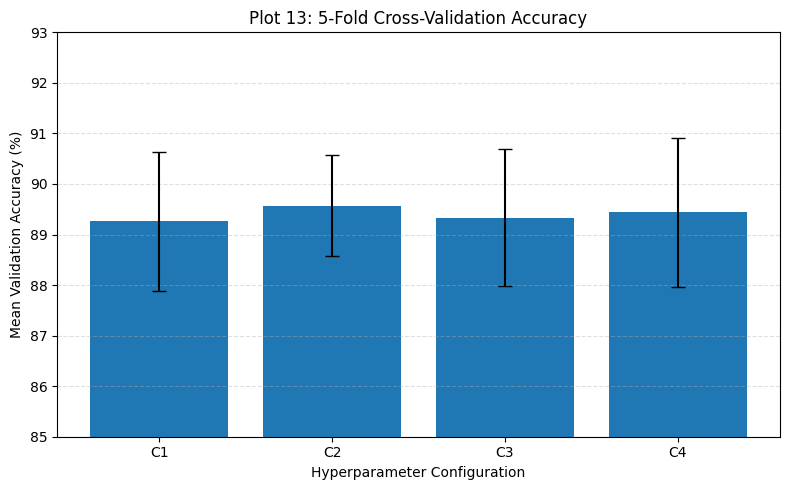

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mean accuracy and standard deviation for each configuration
configurations = ["C1", "C2", "C3", "C4"]

mean_accuracy = [
    c1_mean,
    c2_mean,
    c3_mean,
    c4_mean
]

std_accuracy = [
    c1_sd,
    c2_sd,
    c3_sd,
    c4_sd
]

# Plot with standard deviation error bars
plt.figure(figsize=(8, 5))

plt.bar(
    configurations,
    mean_accuracy,
    yerr=std_accuracy,
    capsize=5
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy")

plt.ylim(85, 93)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save the figure
plt.savefig("Plot_13_KFold_CV_Accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import gc

print("Loading MobileNetV2 for test feature extraction...")

feature_extractor = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")

Loading MobileNetV2 for test feature extraction...
MobileNetV2 loaded successfully.


In [ ]:
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

print("Preprocessing function recreated successfully.")

Preprocessing function recreated successfully.


In [ ]:
# Check the actual structure of test_raw
for images, labels in test_raw.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (500, 403, 3)
Labels shape: ()


In [ ]:
# Check the actual test dataset structure

print("test_raw element spec:")
print(test_raw.element_spec)

for images, labels in test_raw.take(1):
    print("\nActual images shape:", images.shape)
    print("Actual labels shape:", labels.shape)

test_raw element spec:
(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))

Actual images shape: (500, 403, 3)
Actual labels shape: ()


In [ ]:
print("Checking test_raw structure...")

print("Element spec:")
print(test_raw.element_spec)

for images, labels in test_raw.take(1):
    print("Actual images shape:", images.shape)
    print("Actual labels shape:", labels.shape)

Checking test_raw structure...
Element spec:
(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))
Actual images shape: (500, 403, 3)
Actual labels shape: ()


In [ ]:
# Batch and preprocess the test dataset

test_processed = test_raw.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(32)

print("Test dataset batched successfully.")

for images, labels in test_processed.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Test dataset batched successfully.
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [ ]:
print("Extracting MobileNetV2 features from test set...")

X_test_features = []
y_test_features = []

for images, labels in test_processed:
    features = feature_extractor.predict(images, verbose=0)
    X_test_features.append(features)
    y_test_features.append(labels.numpy())

X_test_features = np.concatenate(X_test_features, axis=0)
y_test = np.concatenate(y_test_features, axis=0)

print("Test feature extraction completed!")
print("Test features:", X_test_features.shape)
print("Test labels:", y_test.shape)

Extracting MobileNetV2 features from test set...
Test feature extraction completed!
Test features: (3669, 1280)
Test labels: (3669,)


In [ ]:
del feature_extractor
del test_processed
gc.collect()

print("MobileNetV2 cleared from memory.")
print("Training and test features are ready.")

MobileNetV2 cleared from memory.
Training and test features are ready.


In [ ]:
import time
import gc

gc.collect()

print("Creating final C2 model...")

final_model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

print("Final C2 model created.")
print(f"Number of Parameters: {final_model.count_params():,}")

start_time = time.time()

final_history = final_model.fit(
    X_train_features,
    y_train,
    epochs=3,
    batch_size=16,
    verbose=1
)

training_time = time.time() - start_time

print(f"\nFinal model training completed.")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Number of Parameters: {final_model.count_params():,}")

Creating final C2 model...
Final C2 model created.
Number of Parameters: 168,741
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7602 - loss: 0.9253
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9382 - loss: 0.1949
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0950

Final model training completed.
Training Time: 5.46 seconds
Number of Parameters: 168,741


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

print("Evaluating final model on independent test set...")

# Predict test set
y_pred_prob = final_model.predict(
    X_test_features,
    batch_size=16,
    verbose=1
)

y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
test_accuracy = np.mean(y_pred == y_test)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n===== FINAL MODEL RESULTS =====")
print(f"Mean CV Accuracy: {c2_mean:.2f}%")
print(f"CV Standard Deviation: {c2_sd:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Number of Parameters: {final_model.count_params():,}")

Evaluating final model on independent test set...
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

===== FINAL MODEL RESULTS =====
Mean CV Accuracy: 89.57%
CV Standard Deviation: 1.00%
Test Accuracy: 87.44%
Precision: 88.82%
Recall: 87.44%
F1-score: 87.19%
Training Time: 5.46 seconds
Number of Parameters: 168,741


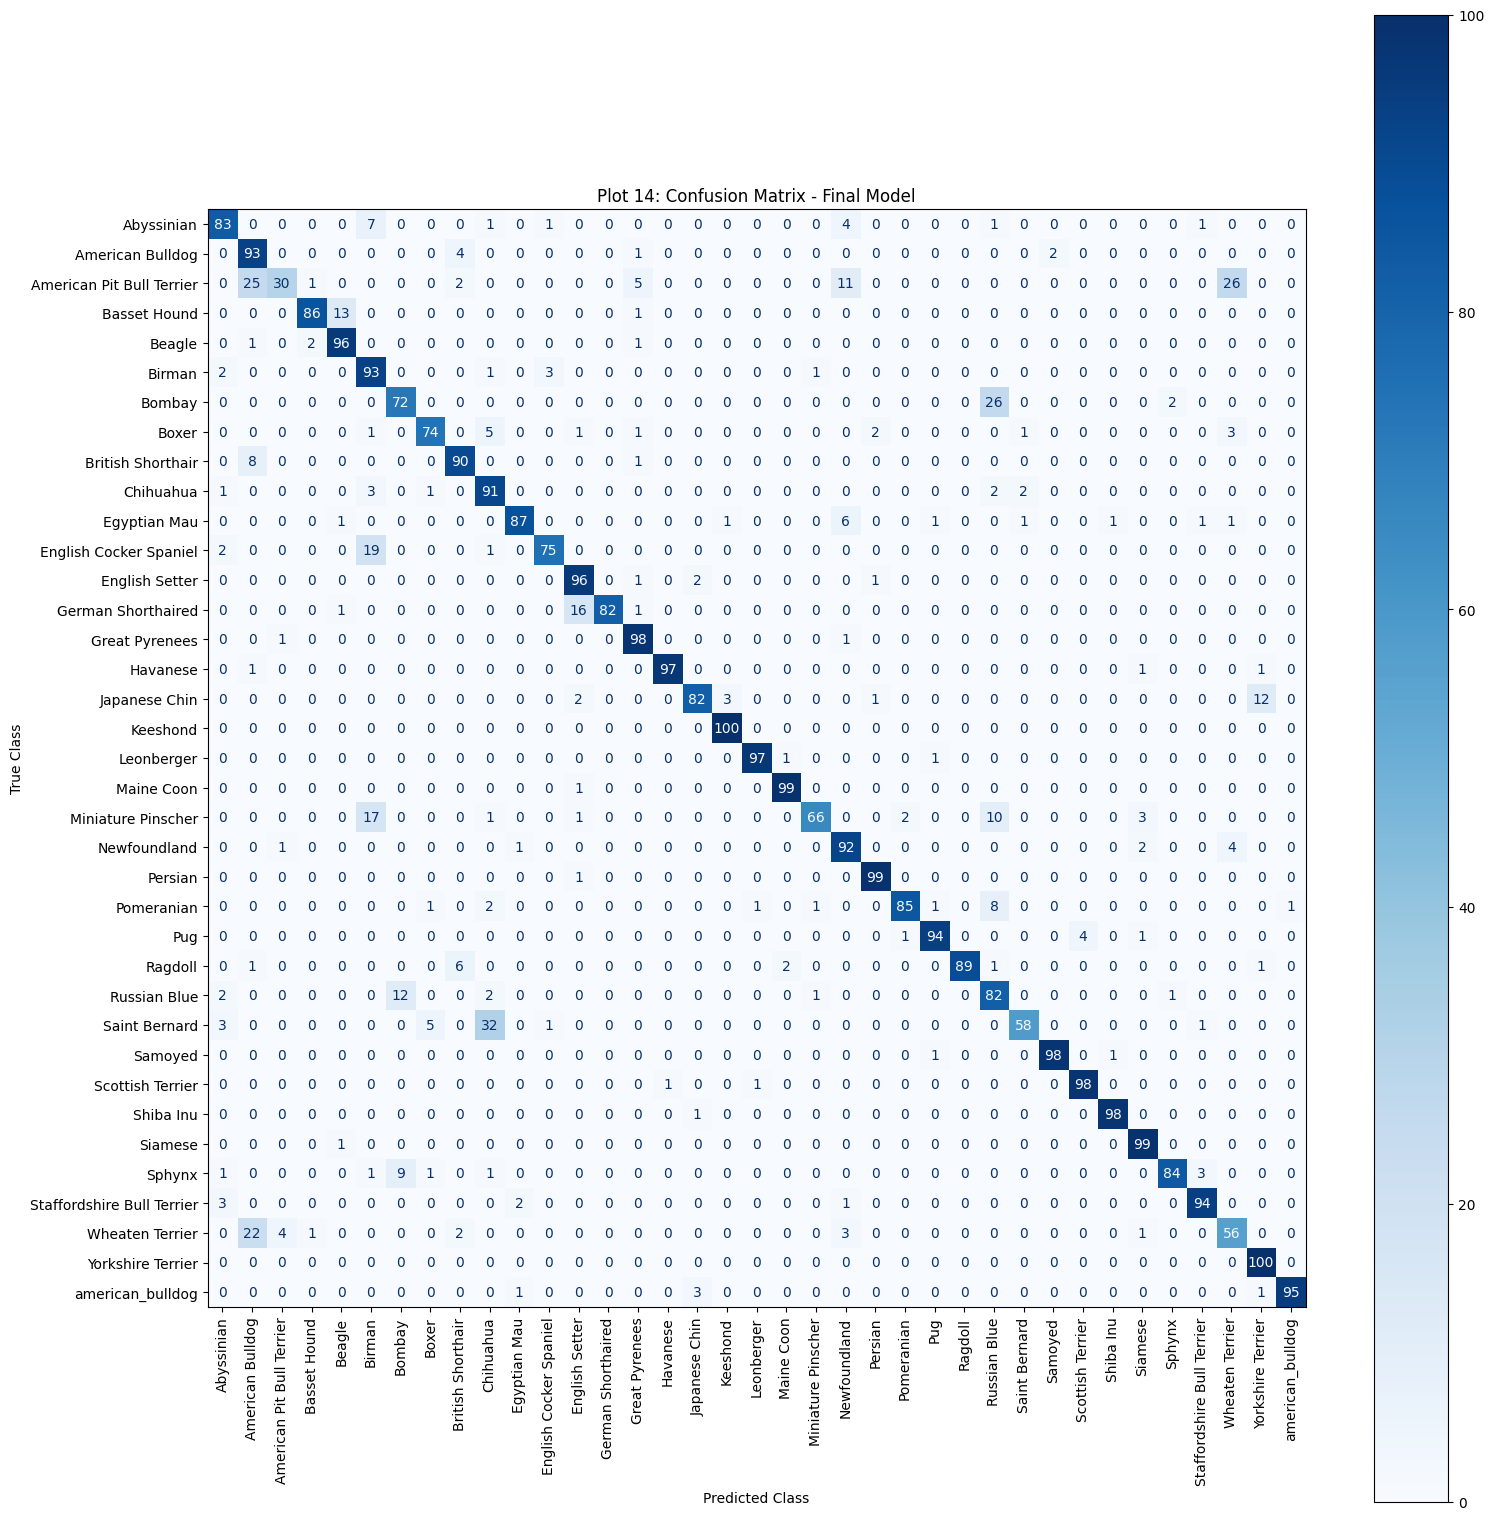

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Class names
class_names = [
    "Abyssinian", "American Bulldog", "American Pit Bull Terrier",
    "Basset Hound", "Beagle", "Birman", "Bombay", "Boxer",
    "British Shorthair", "Chihuahua", "Egyptian Mau",
    "English Cocker Spaniel", "English Setter", "German Shorthaired",
    "Great Pyrenees", "Havanese", "Japanese Chin", "Keeshond",
    "Leonberger", "Maine Coon", "Miniature Pinscher",
    "Newfoundland", "Persian", "Pomeranian", "Pug",
    "Ragdoll", "Russian Blue", "Saint Bernard", "Samoyed",
    "Scottish Terrier", "Shiba Inu", "Siamese", "Sphynx",
    "Staffordshire Bull Terrier", "Wheaten Terrier", "Yorkshire Terrier",
    "american_bulldog"
]

# Display confusion matrix
fig, ax = plt.subplots(figsize=(16, 16))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title("Plot 14: Confusion Matrix - Final Model")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()

plt.savefig(
    "Plot_14_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of classes: 37
Class names: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


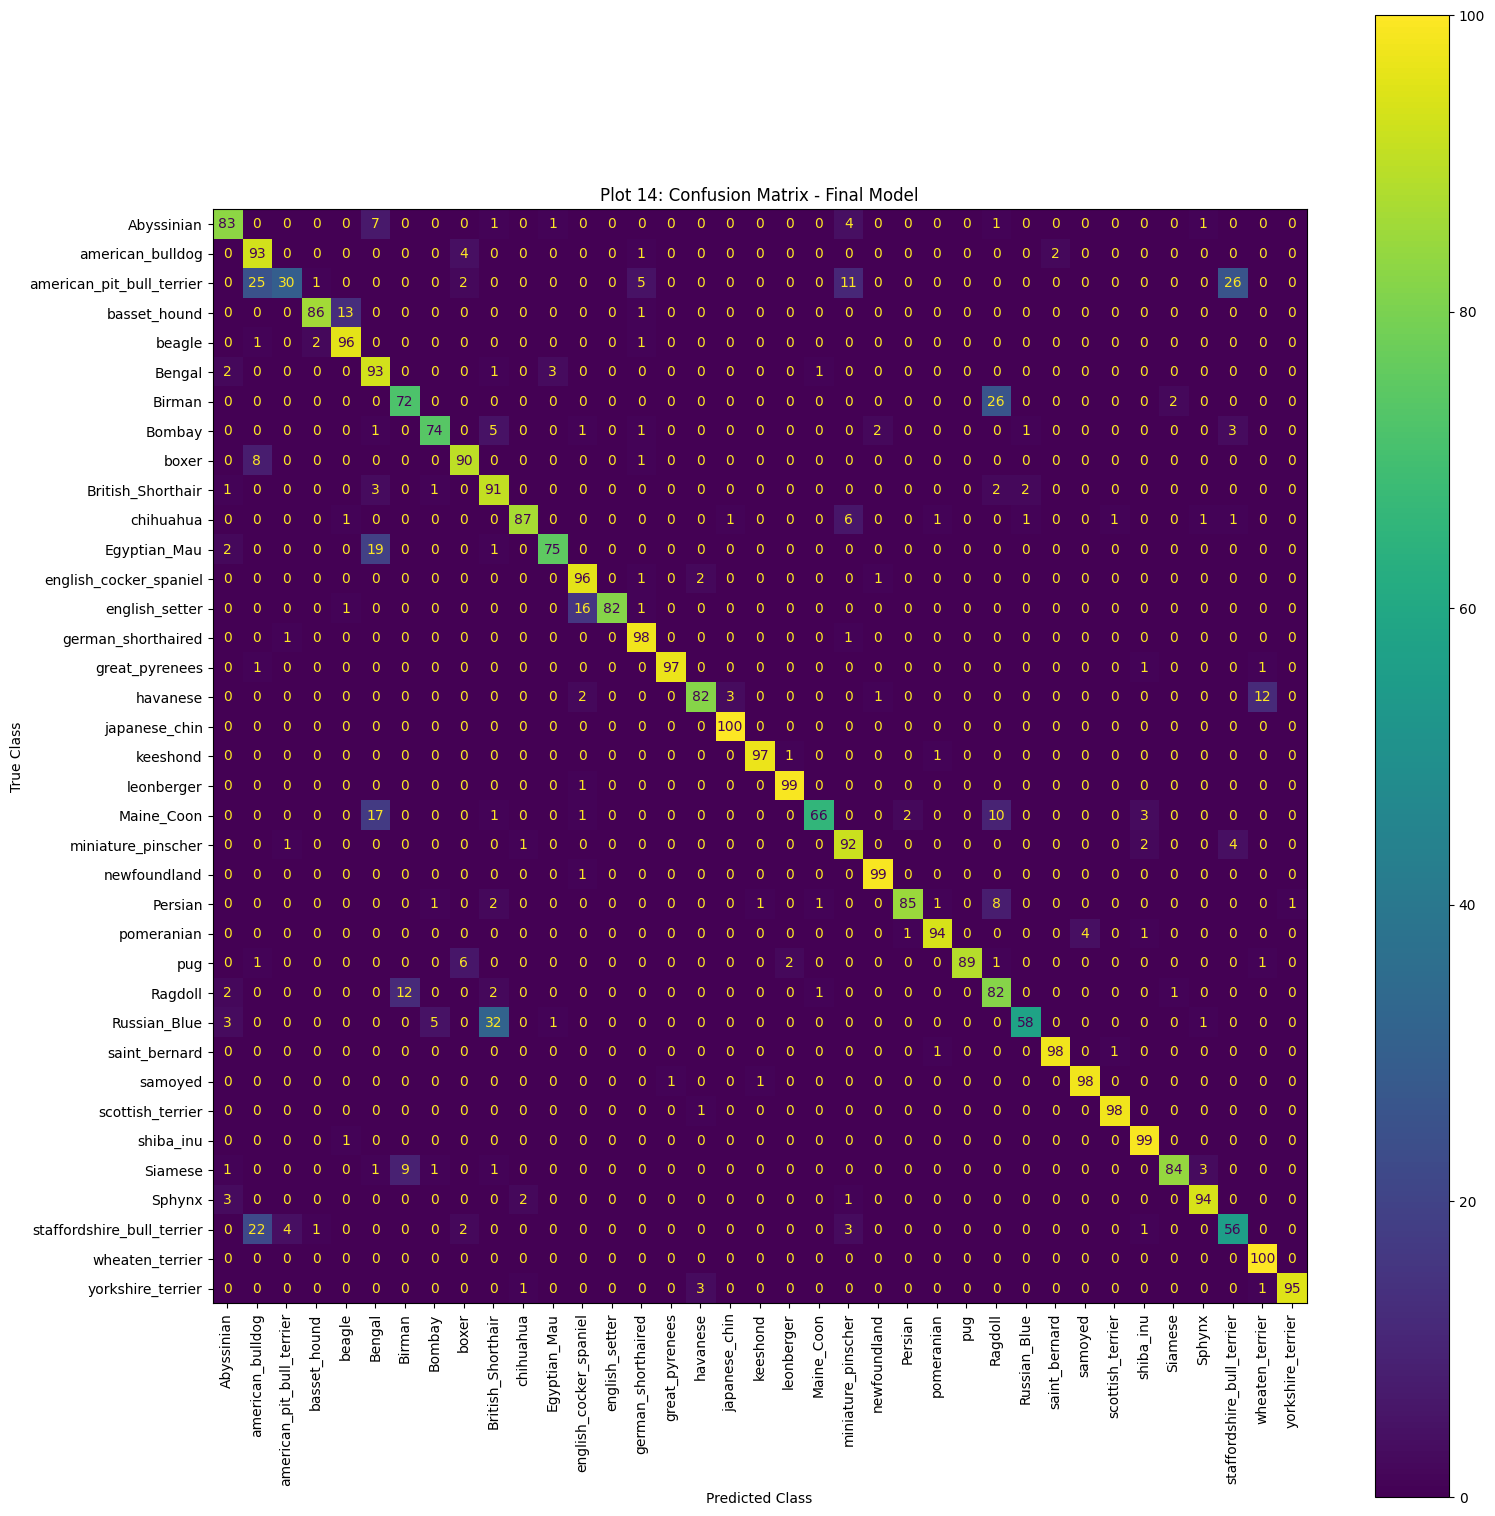

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

# Get the exact class names from the dataset
class_names = info.features["label"].names

print("Number of classes:", len(class_names))
print("Class names:", class_names)

fig, ax = plt.subplots(figsize=(16, 16))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=True
)

plt.title("Plot 14: Confusion Matrix - Final Model")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()

plt.savefig(
    "Plot_14_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Total misclassified images: 461


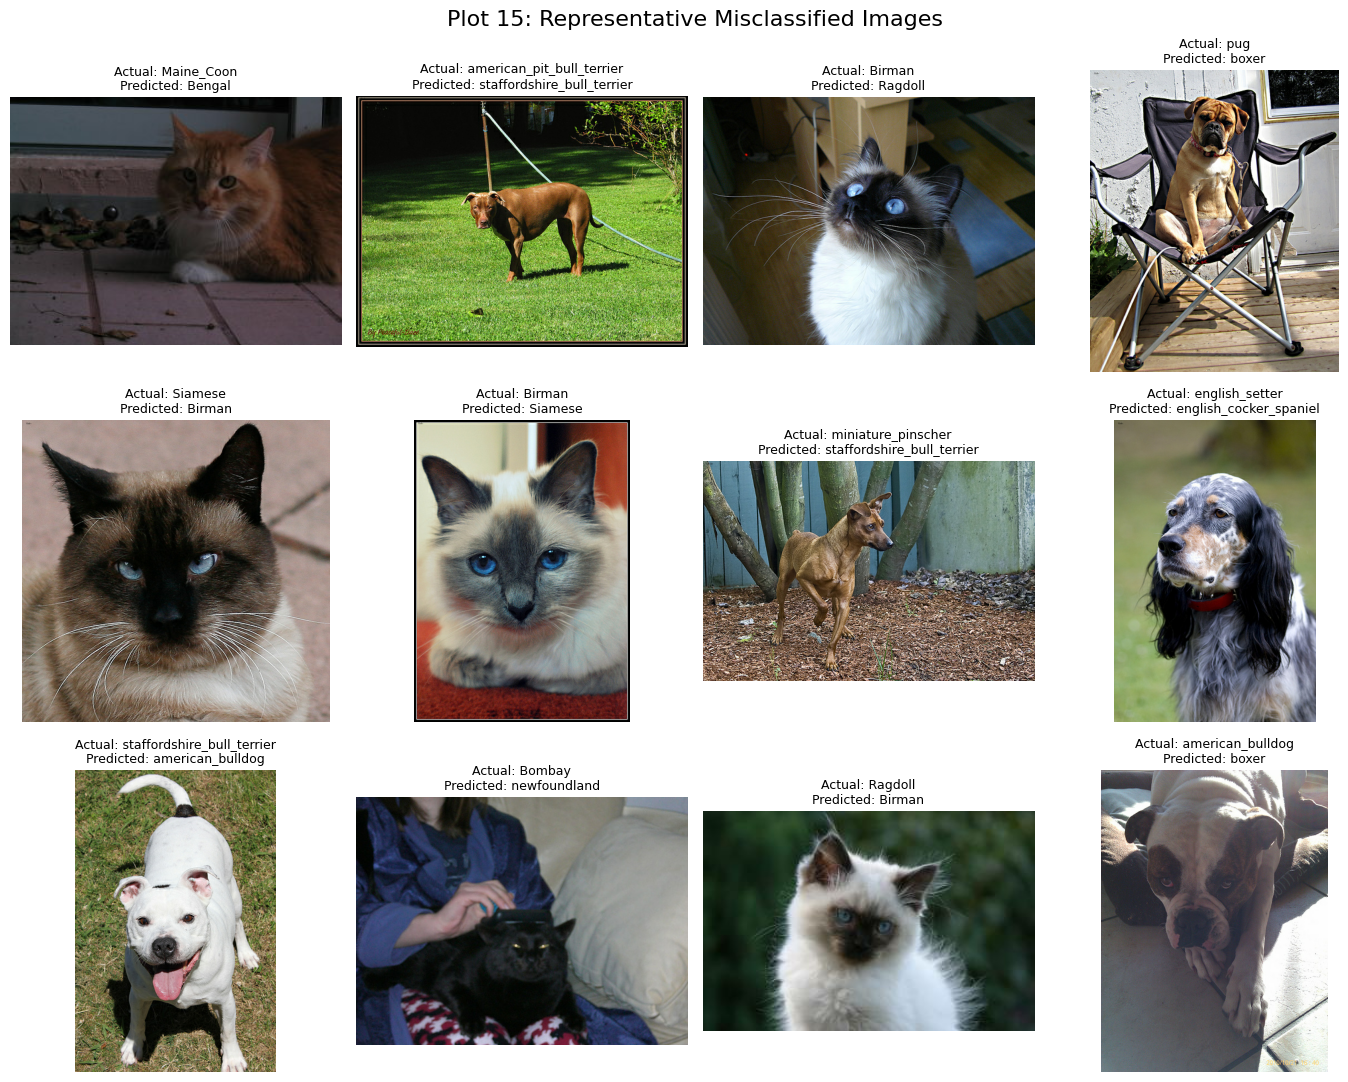

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find misclassified indices
misclassified_indices = np.where(y_pred != y_test)[0]

print("Total misclassified images:", len(misclassified_indices))

# Select up to 12 representative misclassified images
num_images = min(12, len(misclassified_indices))
selected_indices = misclassified_indices[:num_images]

# Get original test images
misclassified_images = []

for i, (image, label) in enumerate(test_raw):
    if i in selected_indices:
        misclassified_images.append(image.numpy())

    if len(misclassified_images) == num_images:
        break

# Class names
class_names = info.features["label"].names

# Plot
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
axes = axes.flatten()

for i, (image, index) in enumerate(zip(misclassified_images, selected_indices)):

    axes[i].imshow(image.astype(np.uint8))

    actual_class = class_names[y_test[index]]
    predicted_class = class_names[y_pred[index]]

    axes[i].set_title(
        f"Actual: {actual_class}\nPredicted: {predicted_class}",
        fontsize=9
    )

    axes[i].axis("off")

# Hide unused axes
for i in range(num_images, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Plot 15: Representative Misclassified Images",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "Plot_15_Misclassified_Images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()